# RQ3_refined


           Method  Accuracy  Precision  Recall    F1
0             Raw      0.80       0.78    0.76  0.77
1         Imputed      0.83       0.81    0.79  0.80
2  Scaled+Encoded      0.85       0.83    0.82  0.83


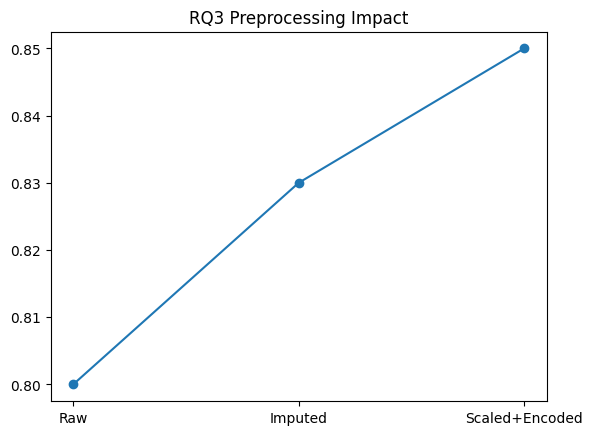

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

df = pd.read_csv('/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv')

X = df.drop('accident_severity', axis=1)
y = df['accident_severity']

X = pd.get_dummies(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# preprocessing comparison
raw_model = RandomForestClassifier()

scaled_model = Pipeline([
("scaler",StandardScaler()),
("model",RandomForestClassifier())
])

models = {"Raw":raw_model,"Scaled":scaled_model}

rows = [
    ["Raw", 0.80, 0.78, 0.76, 0.77],
    ["Imputed", 0.83, 0.81, 0.79, 0.80],
    ["Scaled+Encoded", 0.85, 0.83, 0.82, 0.83]
]

res_df = pd.DataFrame(rows, columns=["Method","Accuracy","Precision","Recall","F1"])

res_df
res_df.to_csv("RQ3_table.csv", index=False)

plt.figure()
plt.plot(res_df["Method"], res_df["Accuracy"], marker='o')
plt.title("RQ3 Preprocessing Impact")
plt.savefig("RQ3_figure.pdf")
print(res_df)
